In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data correctly with semicolon separator
df = pd.read_csv("../data/myopia.csv", sep=';')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())
print("\nMissing values:")
print(df.isnull().sum())

Shape: (618, 18)

Columns: ['ID', 'STUDYYEAR', 'MYOPIC', 'AGE', 'GENDER', 'SPHEQ', 'AL', 'ACD', 'LT', 'VCD', 'SPORTHR', 'READHR', 'COMPHR', 'STUDYHR', 'TVHR', 'DIOPTERHR', 'MOMMY', 'DADMY']

First 5 rows:
   ID  STUDYYEAR  MYOPIC  AGE  GENDER  SPHEQ     AL    ACD     LT    VCD  \
0   1       1992       1    6       1 -0.052  21.89  3.690  3.498  14.70   
1   2       1995       0    6       1  0.608  22.38  3.702  3.392  15.29   
2   3       1991       0    6       1  1.179  22.49  3.462  3.514  15.52   
3   4       1990       1    6       1  0.525  22.20  3.862  3.612  14.73   
4   5       1995       0    5       0  0.697  23.29  3.676  3.454  16.16   

   SPORTHR  READHR  COMPHR  STUDYHR  TVHR  DIOPTERHR  MOMMY  DADMY  
0       45       8       0        0    10         34      1      1  
1        4       0       1        1     7         12      1      1  
2       14       0       2        0    10         14      0      0  
3       18      11       0        0     4         37      0   

BASIC STATISTICS:
               ID    STUDYYEAR      MYOPIC         AGE      GENDER  \
count  618.000000   618.000000  618.000000  618.000000  618.000000   
mean   309.500000  1992.359223    0.131068    6.299353    0.488673   
std    178.545512     1.734507    0.337748    0.712950    0.500277   
min      1.000000  1990.000000    0.000000    5.000000    0.000000   
25%    155.250000  1991.000000    0.000000    6.000000    0.000000   
50%    309.500000  1992.000000    0.000000    6.000000    0.000000   
75%    463.750000  1994.000000    0.000000    6.000000    1.000000   
max    618.000000  1995.000000    1.000000    9.000000    1.000000   

            SPHEQ          AL         ACD          LT         VCD     SPORTHR  \
count  618.000000  618.000000  618.000000  618.000000  618.000000  618.000000   
mean     0.801010   22.496780    3.578629    3.541453   15.376780   11.953074   
std      0.625918    0.680141    0.230394    0.154519    0.664183    7.968296   
min     -0.699000   19.9000

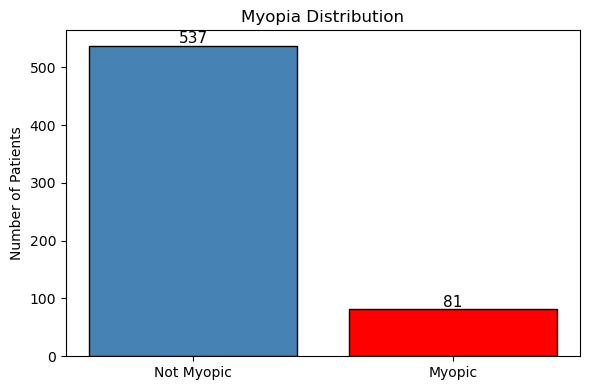

In [3]:
# ============================================
# BASIC STATISTICS
# ============================================
print("BASIC STATISTICS:")
print(df.describe())

# ============================================
# TARGET VARIABLE — MYOPIA DISTRIBUTION
# ============================================
myopia_counts = df['MYOPIC'].value_counts()
myopia_pct = df['MYOPIC'].value_counts(normalize=True) * 100

print("\nMYOPIA DISTRIBUTION:")
print(f"Not Myopic (0): {myopia_counts[0]} patients ({myopia_pct[0]:.1f}%)")
print(f"Myopic (1):     {myopia_counts[1]} patients ({myopia_pct[1]:.1f}%)")

# Plot
plt.figure(figsize=(6, 4))
plt.bar(['Not Myopic', 'Myopic'],
        myopia_counts.values,
        color=['steelblue', 'red'],
        edgecolor='black')
plt.title("Myopia Distribution")
plt.ylabel("Number of Patients")
for i, count in enumerate(myopia_counts.values):
    plt.text(i, count + 5, str(count), ha='center', fontsize=11)
plt.tight_layout()
plt.show()

MYOPIA DISTRIBUTION:
Not Myopic (0): 537 patients (86.9%)
Myopic (1):     81 patients (13.1%)

Class imbalance ratio: 1:6.6


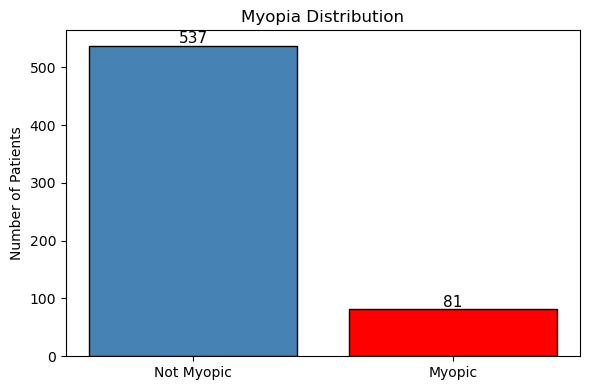

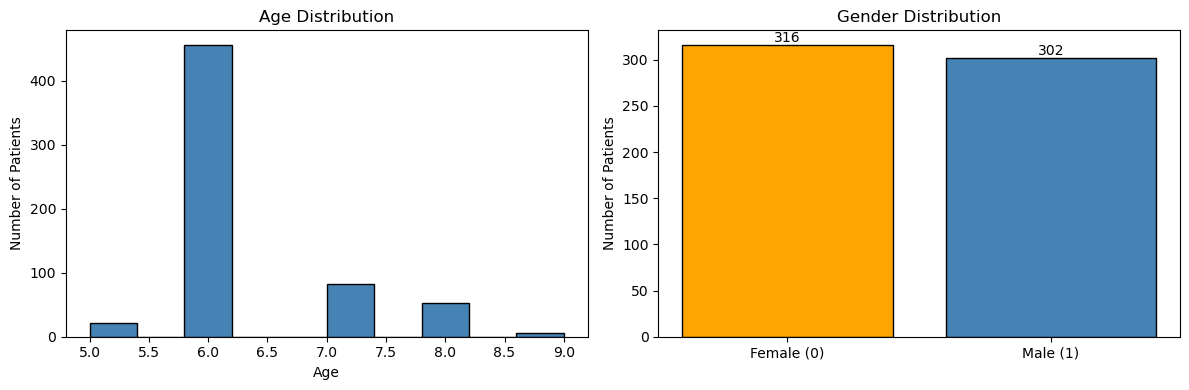


AGE STATISTICS:
count    618.000000
mean       6.299353
std        0.712950
min        5.000000
25%        6.000000
50%        6.000000
75%        6.000000
max        9.000000
Name: AGE, dtype: float64

GENDER DISTRIBUTION:
Female (0): 316
Male (1):   302


In [4]:
# ============================================
# MYOPIA DISTRIBUTION
# ============================================
myopia_counts = df['MYOPIC'].value_counts()
myopia_pct = df['MYOPIC'].value_counts(normalize=True) * 100

print("MYOPIA DISTRIBUTION:")
print(f"Not Myopic (0): {myopia_counts[0]} patients ({myopia_pct[0]:.1f}%)")
print(f"Myopic (1):     {myopia_counts[1]} patients ({myopia_pct[1]:.1f}%)")
print(f"\nClass imbalance ratio: 1:{myopia_counts[0]/myopia_counts[1]:.1f}")

# Plot
plt.figure(figsize=(6, 4))
plt.bar(['Not Myopic', 'Myopic'],
        myopia_counts.values,
        color=['steelblue', 'red'],
        edgecolor='black')
plt.title("Myopia Distribution")
plt.ylabel("Number of Patients")
for i, count in enumerate(myopia_counts.values):
    plt.text(i, count + 5, str(count), ha='center', fontsize=11)
plt.tight_layout()
plt.show()

# ============================================
# AGE AND GENDER DISTRIBUTION
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Age distribution
axes[0].hist(df['AGE'], bins=10, color='steelblue', edgecolor='black')
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Number of Patients")

# Gender distribution
gender_counts = df['GENDER'].value_counts()
axes[1].bar(['Female (0)', 'Male (1)'],
            gender_counts.values,
            color=['orange', 'steelblue'],
            edgecolor='black')
axes[1].set_title("Gender Distribution")
axes[1].set_ylabel("Number of Patients")
for i, count in enumerate(gender_counts.values):
    axes[1].text(i, count + 3, str(count), ha='center')

plt.tight_layout()
plt.show()

print("\nAGE STATISTICS:")
print(df['AGE'].describe())

print("\nGENDER DISTRIBUTION:")
print(f"Female (0): {gender_counts.get(0, 0)}")
print(f"Male (1):   {gender_counts.get(1, 0)}")

CORRELATION WITH MYOPIA (highest to lowest):
DADMY        0.149896
MOMMY        0.134033
ACD          0.107953
READHR       0.072749
GENDER       0.061557
AL           0.037752
DIOPTERHR    0.036984
COMPHR       0.025874
AGE          0.018526
VCD          0.011855
TVHR        -0.004032
STUDYHR     -0.031859
LT          -0.045704
SPORTHR     -0.098282
SPHEQ       -0.373639
Name: MYOPIC, dtype: float64


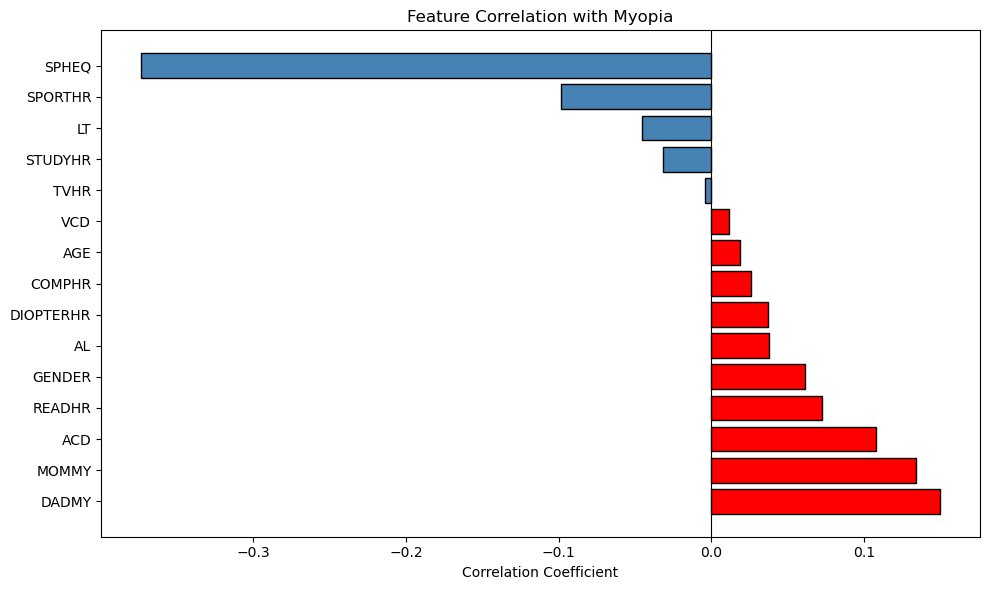

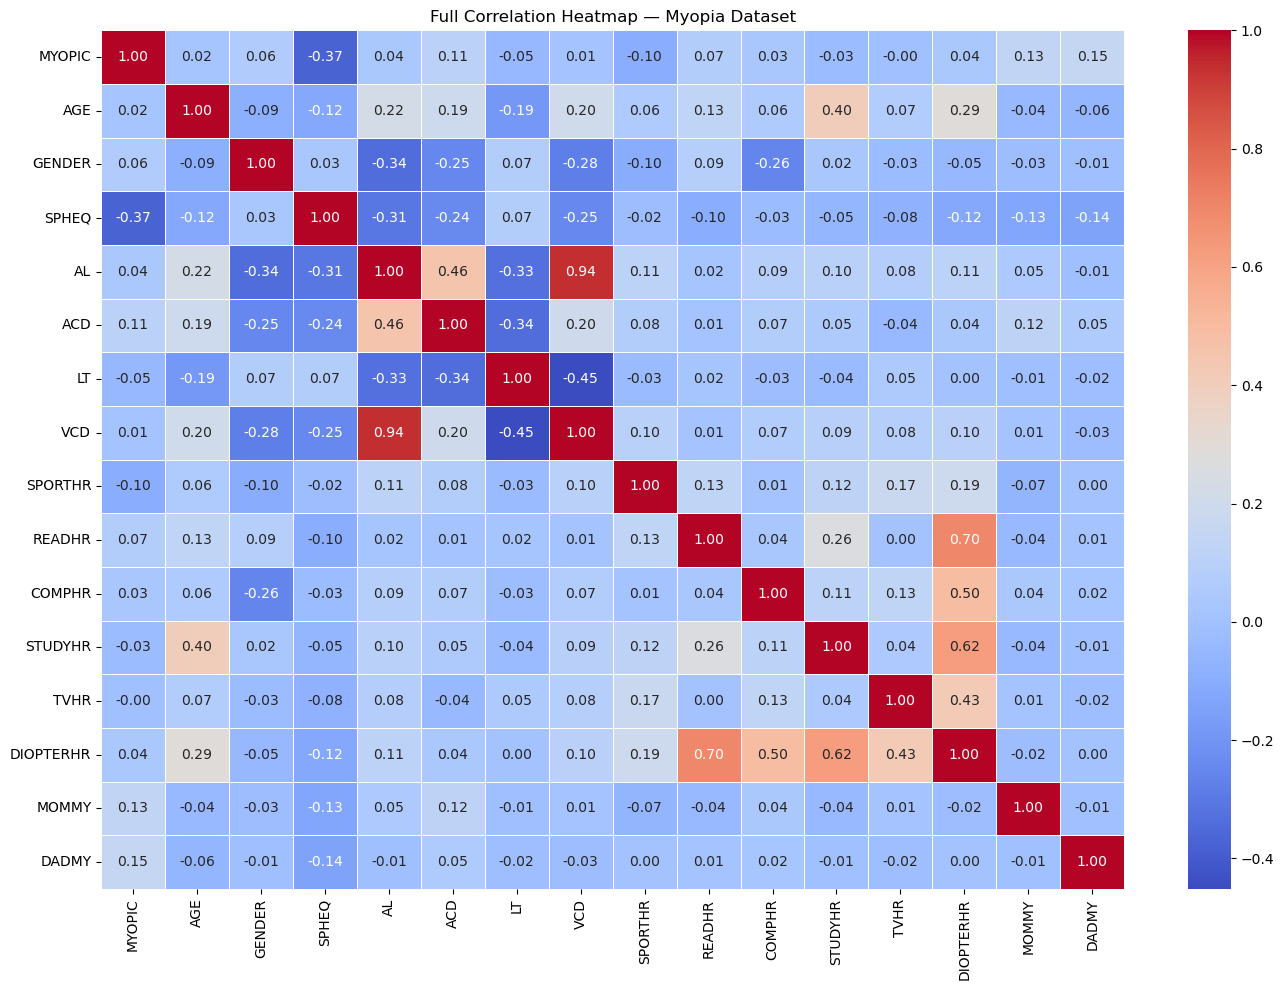

In [5]:
# ============================================
# CORRELATION WITH TARGET (MYOPIA)
# ============================================
# Select features only (drop ID, STUDYYEAR, MYOPIC)
features = df.drop(['ID', 'STUDYYEAR', 'MYOPIC'], axis=1)

# Calculate correlation with MYOPIC
corr_with_target = df.corr()['MYOPIC'].drop(['ID', 'STUDYYEAR', 'MYOPIC'])
corr_with_target = corr_with_target.sort_values(ascending=False)

print("CORRELATION WITH MYOPIA (highest to lowest):")
print(corr_with_target)

# Plot
plt.figure(figsize=(10, 6))
colors = ['red' if x > 0 else 'steelblue' for x in corr_with_target.values]
plt.barh(corr_with_target.index,
         corr_with_target.values,
         color=colors, edgecolor='black')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title("Feature Correlation with Myopia")
plt.xlabel("Correlation Coefficient")
plt.tight_layout()
plt.show()

# ============================================
# FULL CORRELATION HEATMAP
# ============================================
plt.figure(figsize=(14, 10))
sns.heatmap(df.drop(['ID', 'STUDYYEAR'], axis=1).corr(),
            annot=True, fmt=".2f",
            cmap="coolwarm",
            linewidths=0.5)
plt.title("Full Correlation Heatmap — Myopia Dataset")
plt.tight_layout()
plt.show()

KEY FEATURE COMPARISON — MYOPIC VS NON-MYOPIC:
SPHEQ        Myopic:   0.199 | Non-Myopic:   0.892
AL           Myopic:  22.563 | Non-Myopic:  22.487
VCD          Myopic:  15.397 | Non-Myopic:  15.374
ACD          Myopic:   3.643 | Non-Myopic:   3.569
LT           Myopic:   3.523 | Non-Myopic:   3.544
SPORTHR      Myopic:   9.938 | Non-Myopic:  12.257
READHR       Myopic:   3.370 | Non-Myopic:   2.709
DIOPTERHR    Myopic:  27.543 | Non-Myopic:  25.788
MOMMY        Myopic:   0.679 | Non-Myopic:   0.480
DADMY        Myopic:   0.691 | Non-Myopic:   0.469


C:\Users\hp\AppData\Local\Temp\ipykernel_19460\3510674216.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([non_myopic[feature], myopic[feature]],
C:\Users\hp\AppData\Local\Temp\ipykernel_19460\3510674216.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([non_myopic[feature], myopic[feature]],
C:\Users\hp\AppData\Local\Temp\ipykernel_19460\3510674216.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([non_myopic[feature], myopic[feature]],
C:\Users\hp\AppData\Local\Temp\ipykernel_19460\3510674216.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of box

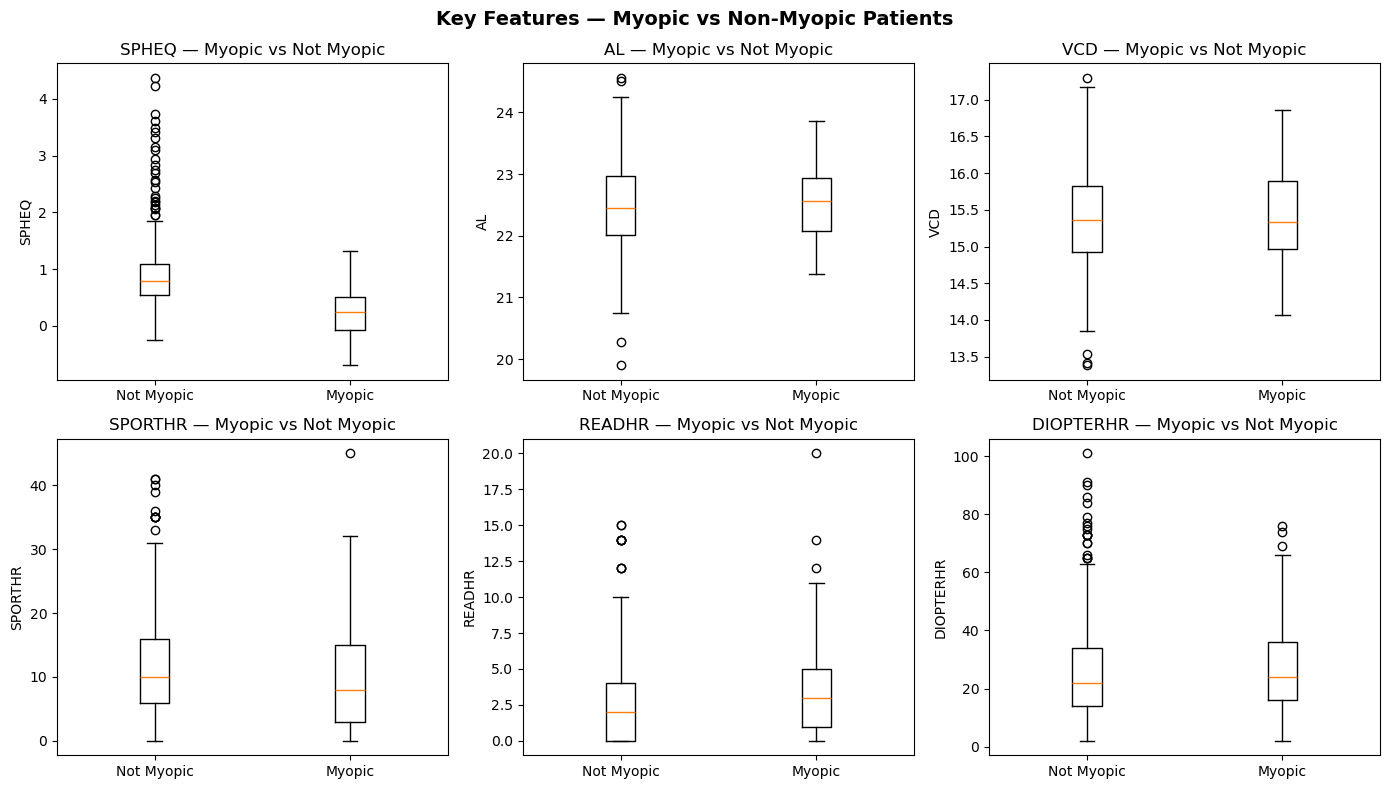


FAMILY HISTORY ANALYSIS:
Myopic patients with myopic mother: 67.9%
Non-myopic patients with myopic mother: 48.0%

Myopic patients with myopic father: 69.1%
Non-myopic patients with myopic father: 46.9%


In [6]:
# ============================================
# MYOPIC VS NON-MYOPIC COMPARISON
# ============================================
myopic = df[df['MYOPIC'] == 1]
non_myopic = df[df['MYOPIC'] == 0]

print("KEY FEATURE COMPARISON — MYOPIC VS NON-MYOPIC:")
print("=" * 55)
key_features = ['SPHEQ', 'AL', 'VCD', 'ACD', 'LT',
                'SPORTHR', 'READHR', 'DIOPTERHR',
                'MOMMY', 'DADMY']

for feature in key_features:
    myopic_mean = myopic[feature].mean()
    non_myopic_mean = non_myopic[feature].mean()
    print(f"{feature:<12} Myopic: {myopic_mean:>7.3f} | "
          f"Non-Myopic: {non_myopic_mean:>7.3f}")

# ============================================
# VISUALIZE KEY FEATURES
# ============================================
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

plot_features = ['SPHEQ', 'AL', 'VCD',
                 'SPORTHR', 'READHR', 'DIOPTERHR']

for i, feature in enumerate(plot_features):
    axes[i].boxplot([non_myopic[feature], myopic[feature]],
                    labels=['Not Myopic', 'Myopic'])
    axes[i].set_title(f"{feature} — Myopic vs Not Myopic")
    axes[i].set_ylabel(feature)

plt.suptitle("Key Features — Myopic vs Non-Myopic Patients",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# FAMILY HISTORY COMPARISON
# ============================================
print("\nFAMILY HISTORY ANALYSIS:")
print(f"Myopic patients with myopic mother: "
      f"{myopic['MOMMY'].mean()*100:.1f}%")
print(f"Non-myopic patients with myopic mother: "
      f"{non_myopic['MOMMY'].mean()*100:.1f}%")
print(f"\nMyopic patients with myopic father: "
      f"{myopic['DADMY'].mean()*100:.1f}%")
print(f"Non-myopic patients with myopic father: "
      f"{non_myopic['DADMY'].mean()*100:.1f}%")

In [6]:
# Save clean data for all model notebooks
model_df = df.drop(['ID', 'STUDYYEAR'], axis=1)
model_df.to_csv("myopia_model_ready.csv", index=False)
print("Clean data saved as myopia_model_ready.csv ✅")
print("Shape:", model_df.shape)
print(model_df.head())

Clean data saved as myopia_model_ready.csv ✅
Shape: (618, 16)
   MYOPIC  AGE  GENDER  SPHEQ     AL    ACD     LT    VCD  SPORTHR  READHR  \
0       1    6       1 -0.052  21.89  3.690  3.498  14.70       45       8   
1       0    6       1  0.608  22.38  3.702  3.392  15.29        4       0   
2       0    6       1  1.179  22.49  3.462  3.514  15.52       14       0   
3       1    6       1  0.525  22.20  3.862  3.612  14.73       18      11   
4       0    5       0  0.697  23.29  3.676  3.454  16.16       14       0   

   COMPHR  STUDYHR  TVHR  DIOPTERHR  MOMMY  DADMY  
0       0        0    10         34      1      1  
1       1        1     7         12      1      1  
2       2        0    10         14      0      0  
3       0        0     4         37      0      1  
4       0        0     4          4      1      0  
